In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


# 1. Perform data quality checks by checking for missing values, if any.

In [8]:
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [10]:
df.notna().sum()

satisfaction_level       14999
last_evaluation          14999
number_project           14999
average_montly_hours     14999
time_spend_company       14999
Work_accident            14999
left                     14999
promotion_last_5years    14999
sales                    14999
salary                   14999
dtype: int64

### No missing values in the data.

In [12]:
df["left"].unique()

array([1, 0], dtype=int64)

In [14]:
df["promotion_last_5years"].unique()

array([0, 1], dtype=int64)

In [16]:
df["number_project"].unique()

array([2, 5, 7, 6, 4, 3], dtype=int64)

In [18]:
df.satisfaction_level.unique()

array([0.38, 0.8 , 0.11, 0.72, 0.37, 0.41, 0.1 , 0.92, 0.89, 0.42, 0.45,
       0.84, 0.36, 0.78, 0.76, 0.09, 0.46, 0.4 , 0.82, 0.87, 0.57, 0.43,
       0.13, 0.44, 0.39, 0.85, 0.81, 0.9 , 0.74, 0.79, 0.17, 0.24, 0.91,
       0.71, 0.86, 0.14, 0.75, 0.7 , 0.31, 0.73, 0.83, 0.32, 0.54, 0.27,
       0.77, 0.88, 0.48, 0.19, 0.6 , 0.12, 0.61, 0.33, 0.56, 0.47, 0.28,
       0.55, 0.53, 0.59, 0.66, 0.25, 0.34, 0.58, 0.51, 0.35, 0.64, 0.5 ,
       0.23, 0.15, 0.49, 0.3 , 0.63, 0.21, 0.62, 0.29, 0.2 , 0.16, 0.65,
       0.68, 0.67, 0.22, 0.26, 0.99, 0.98, 1.  , 0.52, 0.93, 0.97, 0.69,
       0.94, 0.96, 0.18, 0.95])

In [20]:
df.last_evaluation.unique()

array([0.53, 0.86, 0.88, 0.87, 0.52, 0.5 , 0.77, 0.85, 1.  , 0.54, 0.81,
       0.92, 0.55, 0.56, 0.47, 0.99, 0.51, 0.89, 0.83, 0.95, 0.57, 0.49,
       0.46, 0.62, 0.94, 0.48, 0.8 , 0.74, 0.7 , 0.78, 0.91, 0.93, 0.98,
       0.97, 0.79, 0.59, 0.84, 0.45, 0.96, 0.68, 0.82, 0.9 , 0.71, 0.6 ,
       0.65, 0.58, 0.72, 0.67, 0.75, 0.73, 0.63, 0.61, 0.76, 0.66, 0.69,
       0.37, 0.64, 0.39, 0.41, 0.43, 0.44, 0.36, 0.38, 0.4 , 0.42])

In [22]:
df.time_spend_company.unique()

array([ 3,  6,  4,  5,  2,  8, 10,  7], dtype=int64)

In [24]:
df.Work_accident.unique()

array([0, 1], dtype=int64)

In [26]:
df.sales.unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [28]:
df.salary.unique()

array(['low', 'medium', 'high'], dtype=object)

# 2.1. Draw a heatmap of the correlation matrix between all numerical features or columns in the data.

In [30]:
df_copy = df.drop(columns = ['sales','salary'])
df_copy.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
0,0.38,0.53,2,157,3,0,1,0
1,0.80,0.86,5,262,6,0,1,0
2,0.11,0.88,7,272,4,0,1,0
3,0.72,0.87,5,223,5,0,1,0
4,0.37,0.52,2,159,3,0,1,0


In [32]:
df_copy.corr()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
satisfaction_level,1.000000,0.105021,-0.142970,-0.020048,-0.100866,0.058697,-0.388375,0.025605
last_evaluation,0.105021,1.000000,0.349333,0.339742,0.131591,-0.007104,0.006567,-0.008684
number_project,-0.142970,0.349333,1.000000,0.417211,0.196786,-0.004741,0.023787,-0.006064
average_montly_hours,-0.020048,0.339742,0.417211,1.000000,0.127755,-0.010143,0.071287,-0.003544
time_spend_company,-0.100866,0.131591,0.196786,0.127755,1.000000,0.002120,0.144822,0.067433
Work_accident,0.058697,-0.007104,-0.004741,-0.010143,0.002120,1.000000,-0.154622,0.039245
left,-0.388375,0.006567,0.023787,0.071287,0.144822,-0.154622,1.000000,-0.061788
promotion_last_5years,0.025605,-0.008684,-0.006064,-0.003544,0.067433,0.039245,-0.061788,1.000000


<Axes: >

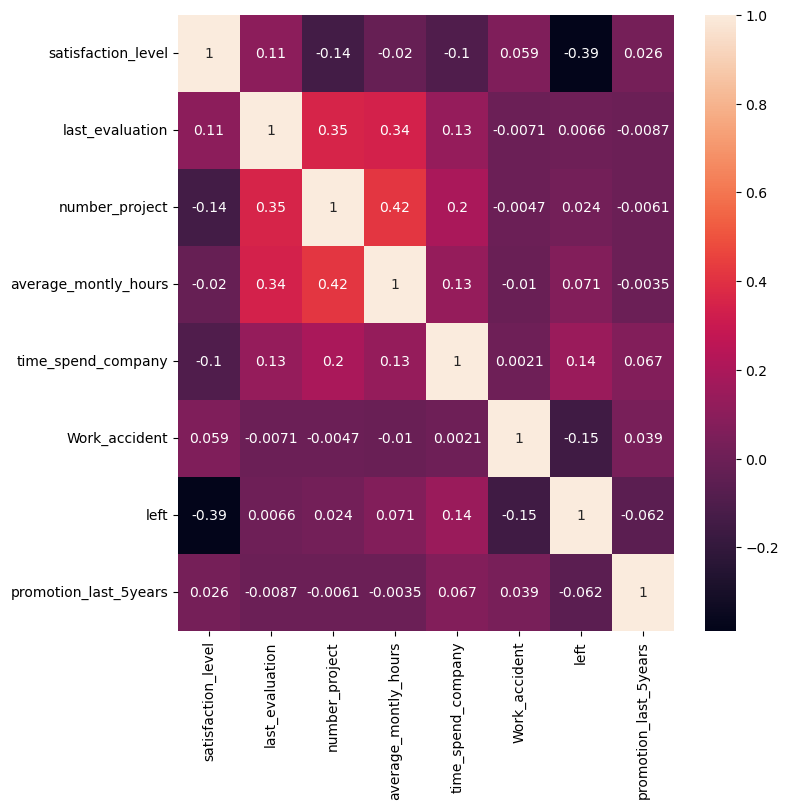

In [34]:
plt.figure(figsize=(8,8))
sns.heatmap(df_copy.corr(),annot=True)

# 2.2. Draw the distribution plot of:
* Employee Satisfaction (use column satisfaction_level)
* Employee Evaluation (use column last_evaluation)
* Employee Average Monthly Hours (use column average_montly_hours)

<Axes: xlabel='satisfaction_level', ylabel='Count'>

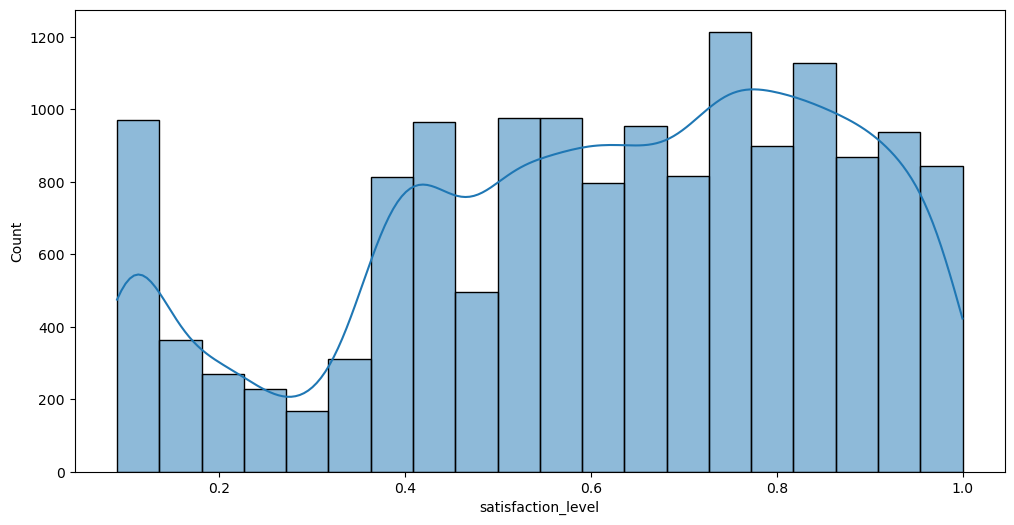

In [36]:
sns.histplot(data = df, x="satisfaction_level", kde = True, bins=20)

<Axes: xlabel='last_evaluation', ylabel='Count'>

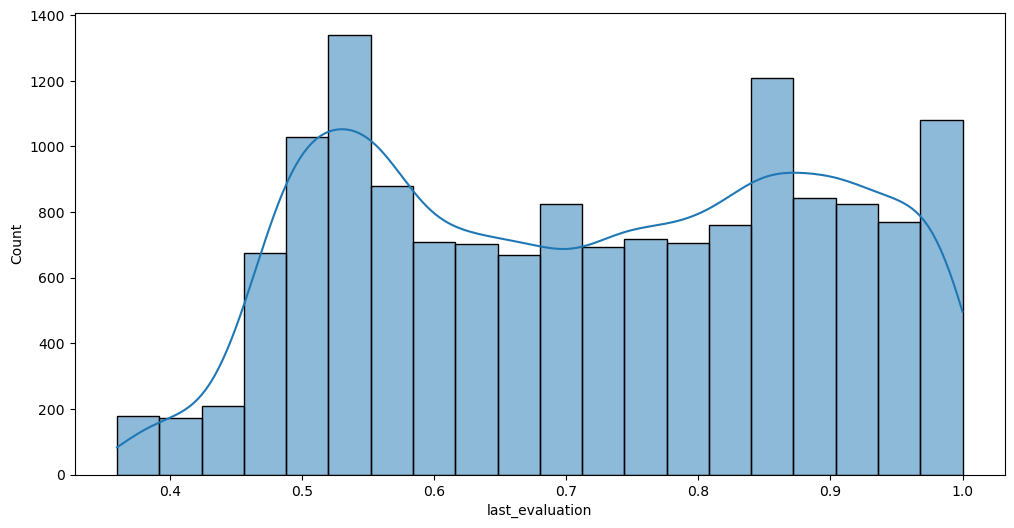

In [40]:
sns.histplot(data = df, x="last_evaluation", kde = True, bins=20)

<Axes: xlabel='average_montly_hours', ylabel='Count'>

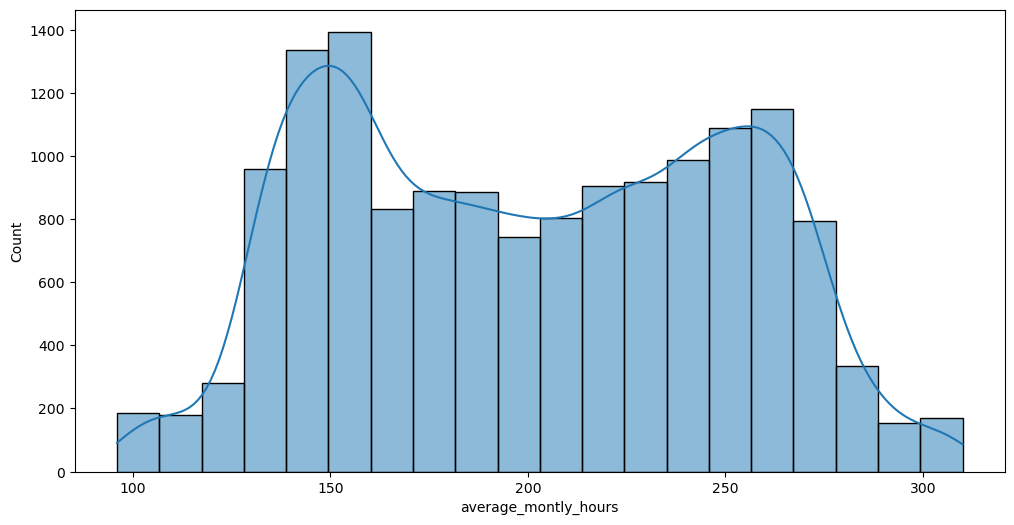

In [37]:
sns.histplot(data = df, x="average_montly_hours", kde = True, bins=20)

# 2.3. 
Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.

In [42]:
dfc_sales = df.groupby(["sales"])["left"].value_counts().reset_index(name="count")
dfc_sales.head()

,sales,left,count
0,IT,0,954
1,IT,1,273
2,RandD,0,666
3,RandD,1,121
4,accounting,0,563


In [46]:
dft_sales = df["sales"].value_counts().reset_index(name="total")
dft_sales.head()

,sales,total
0,sales,4140
1,technical,2720
2,support,2229
3,IT,1227
4,product_mng,902


In [48]:
dfmer_sales = dfc_sales.merge(dft_sales, how="left")
dfmer_sales.head()

,sales,left,count,total
0,IT,0,954,1227
1,IT,1,273,1227
2,RandD,0,666,787
3,RandD,1,121,787
4,accounting,0,563,767


In [50]:
dfmer_sales["percentage"] = dfmer_sales["count"] / dfmer_sales["total"].values * 100
dfmer_sales.head()

,sales,left,count,total,percentage
0,IT,0,954,1227,77.750611
1,IT,1,273,1227,22.249389
2,RandD,0,666,787,84.625159
3,RandD,1,121,787,15.374841
4,accounting,0,563,767,73.402868


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'IT'),
  Text(1, 0, 'RandD'),
  Text(2, 0, 'accounting'),
  Text(3, 0, 'hr'),
  Text(4, 0, 'management'),
  Text(5, 0, 'marketing'),
  Text(6, 0, 'product_mng'),
  Text(7, 0, 'sales'),
  Text(8, 0, 'support'),
  Text(9, 0, 'technical')])

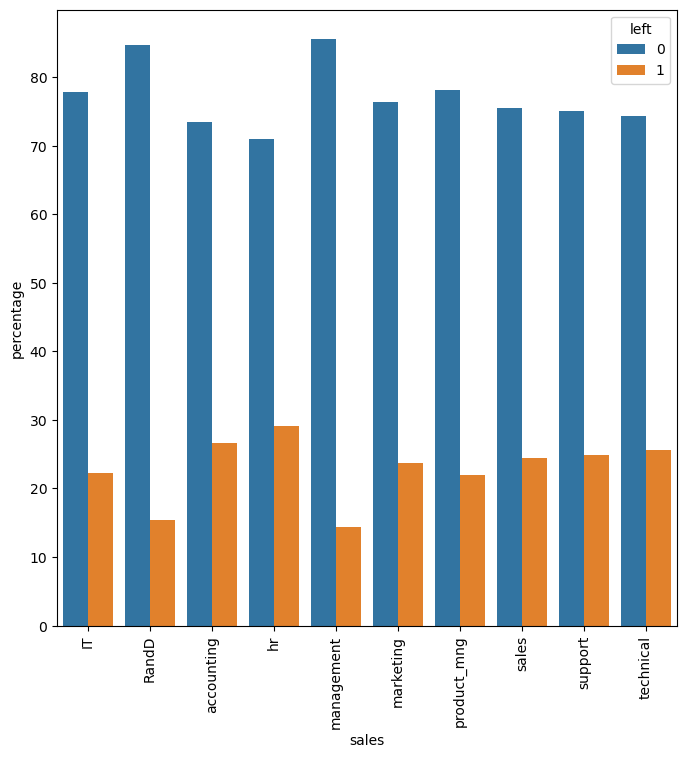

In [52]:
plt.figure(figsize=(8,8))
sns.barplot(data=dfmer_sales, x="sales", y='percentage', hue="left")
plt.xticks(rotation=90)

## People from the hr department are leaving the highest based on the normalized data. The hr department has the highest percentage. Percentage = (Count of people from leaving category in a department)/(Total number of people in that department)*100.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'IT'),
  Text(1, 0, 'RandD'),
  Text(2, 0, 'accounting'),
  Text(3, 0, 'hr'),
  Text(4, 0, 'management'),
  Text(5, 0, 'marketing'),
  Text(6, 0, 'product_mng'),
  Text(7, 0, 'sales'),
  Text(8, 0, 'support'),
  Text(9, 0, 'technical')])

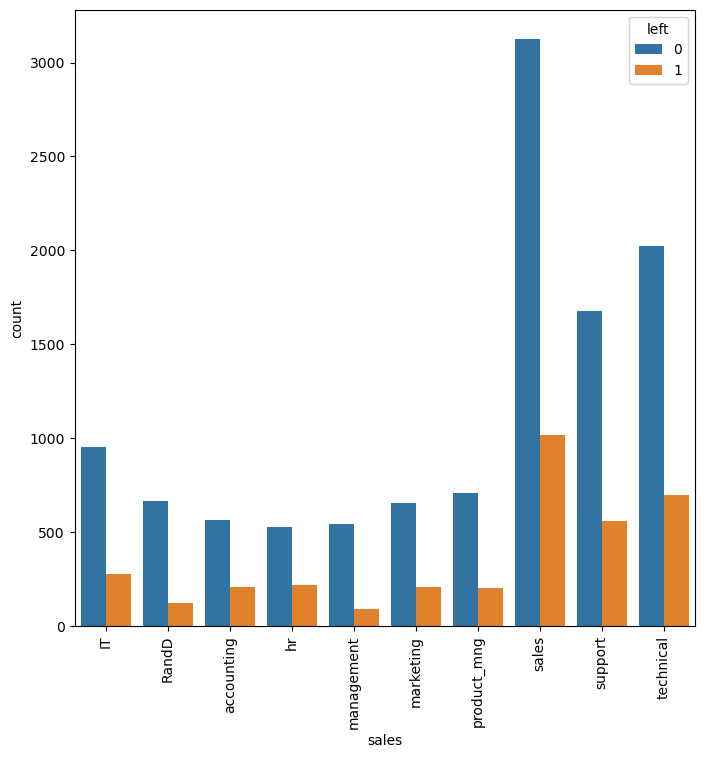

In [54]:
plt.figure(figsize=(8,8))
sns.barplot(data=dfc_sales, x="sales", y='count', hue="left")
plt.xticks(rotation=90)

## The most number of people leaving are from the sales department.

In [56]:
dfc_salary = df.groupby(["salary"])["left"].value_counts().reset_index(name="count")
dfc_salary.head()

,salary,left,count
0,high,0,1155
1,high,1,82
2,low,0,5144
3,low,1,2172
4,medium,0,5129


In [58]:
dft_salary = df["salary"].value_counts().reset_index(name="total")
dft_salary.head()

,salary,total
0,low,7316
1,medium,6446
2,high,1237


In [60]:
dfmer_salary = dfc_salary.merge(dft_salary, how="left")
dfmer_salary.head()

,salary,left,count,total
0,high,0,1155,1237
1,high,1,82,1237
2,low,0,5144,7316
3,low,1,2172,7316
4,medium,0,5129,6446


In [62]:
dfmer_salary["percentage"] = dfmer_salary["count"] / dfmer_salary["total"].values * 100
dfmer_salary.head()

,salary,left,count,total,percentage
0,high,0,1155,1237,93.371059
1,high,1,82,1237,6.628941
2,low,0,5144,7316,70.311646
3,low,1,2172,7316,29.688354
4,medium,0,5129,6446,79.568725


([0, 1, 2], [Text(0, 0, 'high'), Text(1, 0, 'low'), Text(2, 0, 'medium')])

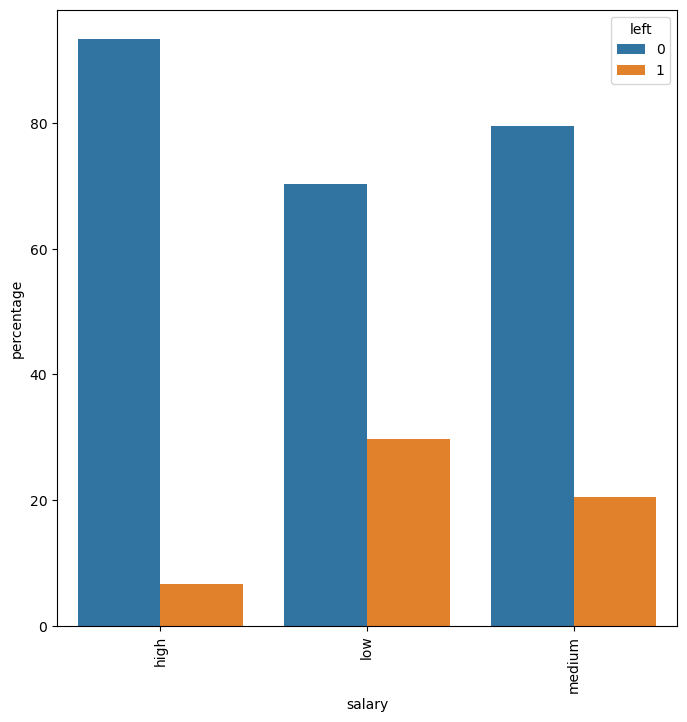

In [64]:
plt.figure(figsize=(8,8))
sns.barplot(data=dfmer_salary, x="salary", y='percentage', hue="left")
plt.xticks(rotation=90)

([0, 1, 2], [Text(0, 0, 'high'), Text(1, 0, 'low'), Text(2, 0, 'medium')])

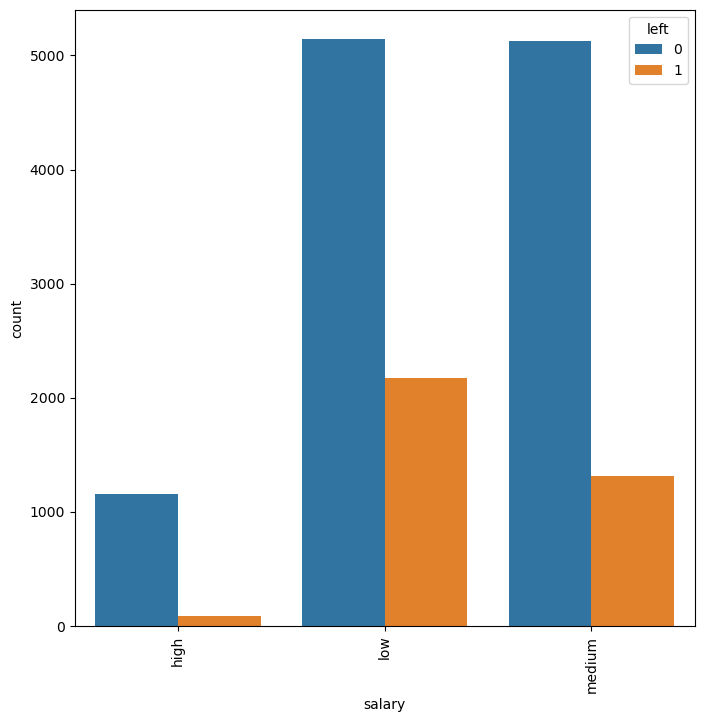

In [66]:
plt.figure(figsize=(8,8))
sns.barplot(data=dfc_salary, x="salary", y='count', hue="left")
plt.xticks(rotation=90)

## People with lower salaries are leaving the company, while people with comparatively higher salaries are staying back.

In [68]:
dfc_timespend = df.groupby(["time_spend_company"])["left"].value_counts().reset_index(name="count")
dfc_timespend.head()

,time_spend_company,left,count
0,2,0,3191
1,2,1,53
2,3,0,4857
3,3,1,1586
4,4,0,1667


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, '2'),
  Text(1, 0, '3'),
  Text(2, 0, '4'),
  Text(3, 0, '5'),
  Text(4, 0, '6'),
  Text(5, 0, '7'),
  Text(6, 0, '8'),
  Text(7, 0, '10')])

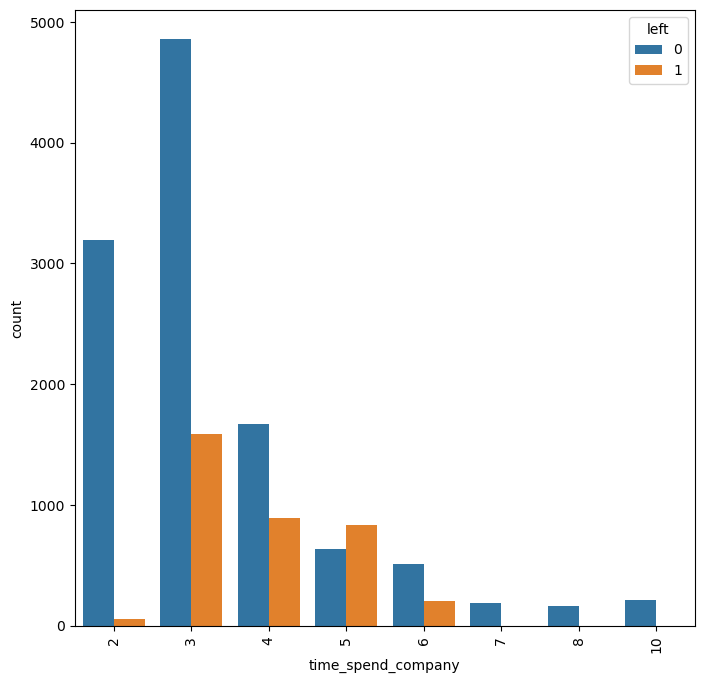

In [70]:
plt.figure(figsize=(8,8))
sns.barplot(data=dfc_timespend, x="time_spend_company", y='count', hue="left",)
plt.xticks(rotation=90)

## People with experience of 3 to 5 years is more prone to leaving the company.

([0, 1], [Text(0, 0, '0'), Text(1, 0, '1')])

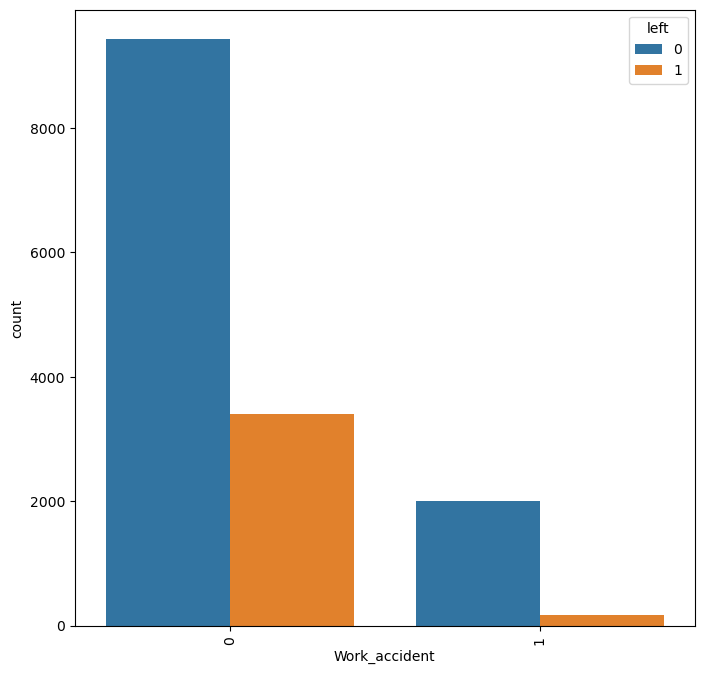

In [72]:
plt.figure(figsize=(8,8))
sns.countplot(data=df, x="Work_accident", hue="left")
plt.xticks(rotation=90)

## People with no accident during the work tenure are staying back.

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, '2'),
  Text(1, 0, '3'),
  Text(2, 0, '4'),
  Text(3, 0, '5'),
  Text(4, 0, '6'),
  Text(5, 0, '7')])

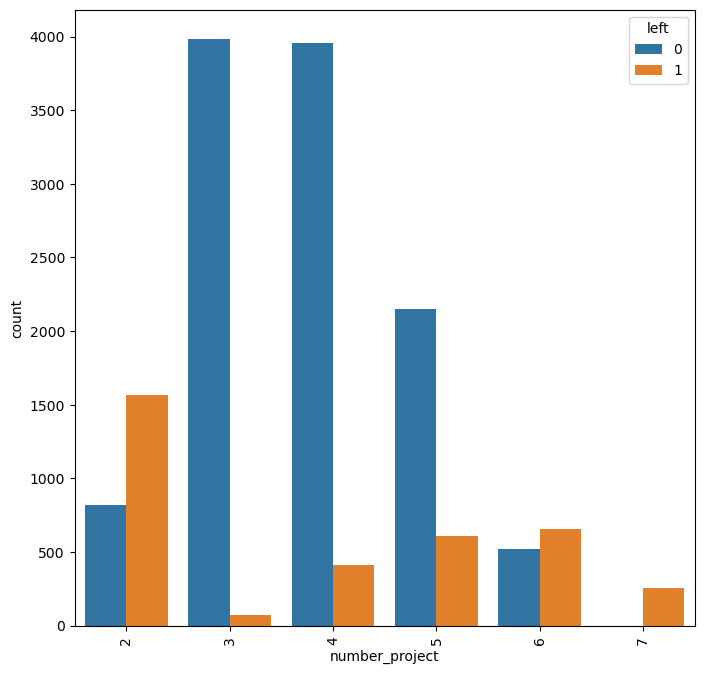

In [74]:
plt.figure(figsize=(8,8))
sns.countplot(data=df, x="number_project", hue="left")
plt.xticks(rotation=90)

## People who have worked on 3 or 4 projects are more prone to leaving the organization.

# 3.1. Choose columns satisfaction_level, last_evaluation, and left.

In [76]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

In [77]:
df_cluster = df[["satisfaction_level","last_evaluation","left"]]
df_cluster

,satisfaction_level,last_evaluation,left
0,0.38,0.53,1
1,0.80,0.86,1
2,0.11,0.88,1
3,0.72,0.87,1
4,0.37,0.52,1
...,...,...,...
14994,0.40,0.57,1
14995,0.37,0.48,1
14996,0.37,0.53,1
14997,0.11,0.96,1


# 3.2. Do K-means clustering of employees who left the company into 3 clusters.

[[0.81  0.74  0.   ]
 [0.44  0.718 1.   ]
 [0.453 0.679 0.   ]]

{0: 6816, 1: 3571, 2: 4612}


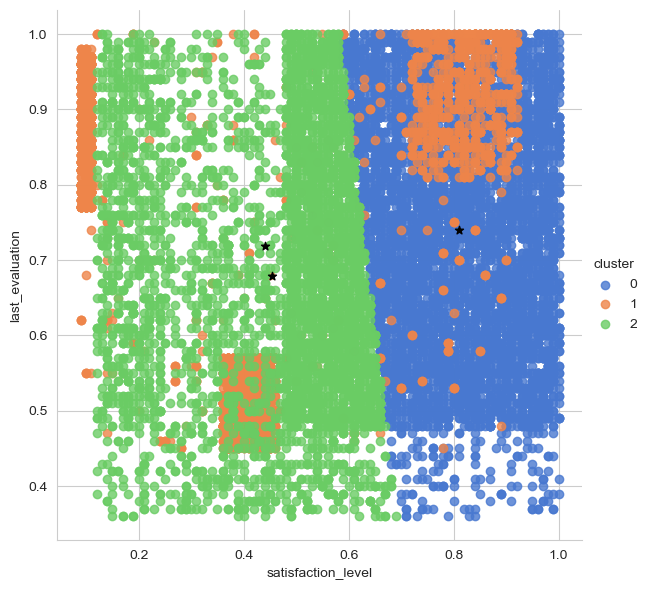

In [80]:
df_analyze = df_cluster.copy()

kmeans = KMeans(n_clusters=3)
kmeans.fit(df_analyze)

print(np.round(kmeans.cluster_centers_,3))
print ()
unique, counts = np.unique(kmeans.labels_,return_counts=True)
print(dict(zip(unique, counts)))

df_analyze['cluster'] = kmeans.labels_
sns.set_style('whitegrid')

sns.lmplot(x='satisfaction_level', y='last_evaluation',
           data=df_analyze, hue='cluster',
           palette='muted',height=6,aspect=1,fit_reg=False)

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1], marker="*", color='black')

plt.show()

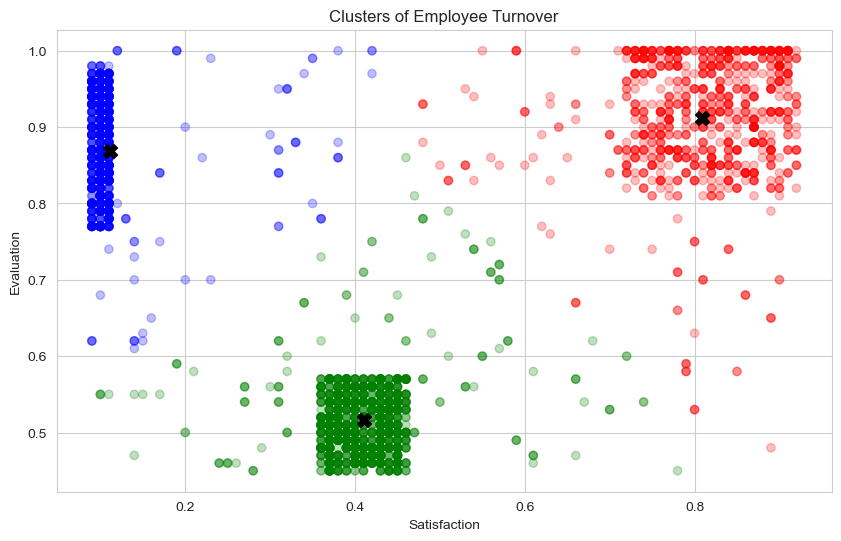

In [90]:
df_analyze_mod = df_cluster.copy()

kmeans_mod = KMeans(n_clusters=3,random_state=2)
kmeans_mod.fit(df_analyze_mod[df_analyze_mod.left==1][["satisfaction_level","last_evaluation"]])

kmeans_colors = ['green' if c == 0 else 'blue' if c == 2 else 'red' for c in kmeans_mod.labels_]

fig = plt.figure(figsize=(10, 6))
plt.scatter(x="satisfaction_level",y="last_evaluation", data=df_analyze_mod[df_analyze_mod.left==1],
            alpha=0.25,color = kmeans_colors)
plt.xlabel("Satisfaction")
plt.ylabel("Evaluation")
plt.scatter(x=kmeans_mod.cluster_centers_[:,0],y=kmeans_mod.cluster_centers_[:,1],color="black",marker="X",s=100)
plt.title("Clusters of Employee Turnover")
plt.show();

In [92]:
km = df_cluster.iloc[:,:].values
print(km[0,:])

label = kmeans.fit_predict(df_cluster)
labelarr = kmeans.fit_predict(km)

print(label)
print(labelarr)

print(label == 0,0)
print(label == 0,1)
print(label == 1,0)
print(label == 1,1)
print(label == 2,0)
print(label == 2,1)

[0.38 0.53 1.  ]
[1 1 1 ... 1 1 1]
[1 1 1 ... 1 1 1]
[False False False ... False False False] 0
[False False False ... False False False] 1
[ True  True  True ...  True  True  True] 0
[ True  True  True ...  True  True  True] 1
[False False False ... False False False] 0
[False False False ... False False False] 1


In [94]:
df_cluster.describe()

,satisfaction_level,last_evaluation,left
count,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,0.238083
std,0.248631,0.171169,0.425924
min,0.090000,0.360000,0.000000
25%,0.440000,0.560000,0.000000
50%,0.640000,0.720000,0.000000
75%,0.820000,0.870000,0.000000
max,1.000000,1.000000,1.000000


In [96]:
df_cluster[label==0].describe()

,satisfaction_level,last_evaluation,left
count,6815.000000,6815.000000,6815.0
mean,0.810650,0.739056,0.0
std,0.109433,0.155099,0.0
min,0.590000,0.360000,0.0
25%,0.720000,0.610000,0.0
50%,0.810000,0.740000,0.0
75%,0.910000,0.870000,0.0
max,1.000000,1.000000,0.0


In [98]:
df_cluster[label==1].describe()

,satisfaction_level,last_evaluation,left
count,3571.000000,3571.000000,3571.0
mean,0.440098,0.718113,1.0
std,0.263933,0.197673,0.0
min,0.090000,0.450000,1.0
25%,0.130000,0.520000,1.0
50%,0.410000,0.790000,1.0
75%,0.730000,0.900000,1.0
max,0.920000,1.000000,1.0


In [100]:
df_cluster[label==2].describe()

,satisfaction_level,last_evaluation,left
count,4613.000000,4613.000000,4613.0
mean,0.454307,0.680633,0.0
std,0.152804,0.165683,0.0
min,0.120000,0.360000,0.0
25%,0.340000,0.550000,0.0
50%,0.510000,0.670000,0.0
75%,0.570000,0.810000,0.0
max,0.680000,1.000000,0.0


In [102]:
print(km[label==0,0])
print(km[label==0,1])
print(km[label==1,0])
print(km[label==1,1])
print(km[label==2,0])
print(km[label==2,1])

[0.82 0.78 0.99 ... 0.9  0.74 0.85]
[0.67 0.82 0.91 ... 0.55 0.95 0.54]
[0.38 0.8  0.11 ... 0.37 0.11 0.37]
[0.53 0.86 0.88 ... 0.53 0.96 0.52]
[0.58 0.45 0.49 ... 0.22 0.33 0.5 ]
[0.74 0.69 0.6  ... 0.94 0.65 0.73]


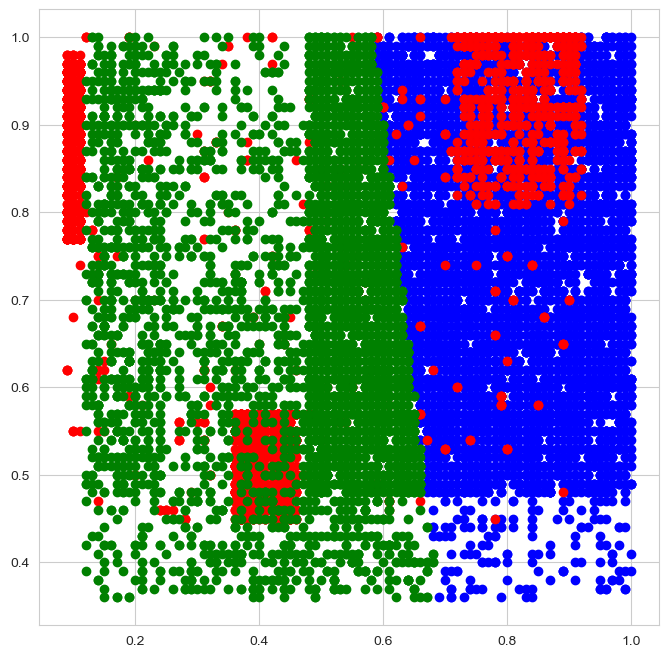

In [104]:
plt.figure(figsize=(8,8))
plt.scatter(km[label==0,0],km[label==0,1],color="blue")
plt.scatter(km[label==1,0],km[label==1,1],color="red")
plt.scatter(km[label==2,0],km[label==2,1],color="green")

# 3.3. Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.

## The Blue cluster denotes people with high and above average satisfaction levels and scored moderate to high in the last evaluation.

## The Red cluster denotes people with highly scattered and below average satisfaction levels and scored moderate to high in the last evaluation

## The Green cluster denotes people with low and below average satisfaction levels and scored fairly than the other clusters on an average.

# 4.1. Pre-process the data by converting categorical columns to numerical columns by:

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


## Separating categorical variables and numeric variables.

In [129]:
df_numerical = df.select_dtypes(include=['int64','float64'])
df_categorical = df.select_dtypes(include=['object'])

## Applying get_dummies() to the categorical variables.

In [131]:
df_categorical = df_categorical.join(pd.get_dummies(df_categorical.sales, prefix='sales', dummy_na=True))
df_categorical = df_categorical.drop(['sales','sales_IT'], axis = 1)
df_categorical = df_categorical.join(pd.get_dummies(df_categorical.salary, prefix='salary', dummy_na=True))
df_categorical = df_categorical.drop(['salary','salary_high'], axis = 1)

In [133]:
df_categorical.head()

,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,sales_nan,salary_low,salary_medium,salary_nan
0,False,False,False,False,False,False,True,False,False,False,True,False,False
1,False,False,False,False,False,False,True,False,False,False,False,True,False
2,False,False,False,False,False,False,True,False,False,False,False,True,False
3,False,False,False,False,False,False,True,False,False,False,True,False,False
4,False,False,False,False,False,False,True,False,False,False,True,False,False


## Combining categorical variables and numeric variables.

In [135]:
df_joined = pd.concat([df_numerical, df_categorical], axis=1, join="inner")

In [139]:
df_joined.shape

(14999, 21)

In [141]:
df_joined.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,...,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,sales_nan,salary_low,salary_medium,salary_nan
0,0.38,0.53,2,157,3,0,1,0,False,False,...,False,False,False,True,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0.11,0.88,7,272,4,0,1,0,False,False,...,False,False,False,True,False,False,False,False,True,False
3,0.72,0.87,5,223,5,0,1,0,False,False,...,False,False,False,True,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,False,False,...,False,False,False,True,False,False,False,True,False,False


# 4.2. Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.

In [174]:
X = df_joined.drop("left",axis=1)
y = df_joined["left"]

In [176]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 123, stratify=y)

In [178]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((11999, 20), (11999,), (3000, 20), (3000,))

# 4.3. Upsample the train dataset using the SMOTE technique from the imblearn module.

In [180]:
print(round(y_train.value_counts(1),2))

left
0    0.76
1    0.24
Name: proportion, dtype: float64


## Data is highly imbalanced for the training dataset as the number of people who left is very low in comparision to the number of people who did not leave. Using SMOTE to handle the imbalance for the left category.

In [182]:
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE 

sm = SMOTE(random_state=12, sampling_strategy = 1.0)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [184]:
print("Original shape:", X_train.shape, y_train.shape)
print("SMOTE sample shape:", X_train_sm.shape, y_train_sm.shape)

Original shape: (11999, 20) (11999,)
SMOTE sample shape: (18284, 20) (18284,)


# 5.1. Train a logistic regression model, apply a 5-fold CV, and plot the classification report.

In [337]:
from statistics import mean
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

In [307]:
kf = KFold(n_splits=5, random_state=42, shuffle=True)

In [309]:
from sklearn.linear_model import LogisticRegression
model_log_reg = LogisticRegression()

In [311]:
k_fold_scores_log_reg = cross_val_score(model_log_reg, X_train, y_train, scoring='accuracy', cv = kf, n_jobs = -1)
print(np.round(k_fold_scores_log_reg, 2))
print(np.mean(k_fold_scores_log_reg))

[0.79 0.8  0.8  0.81 0.81]
0.8014006530498818


In [313]:
model_log_reg.fit(X_train, y_train)
y_pred_train_log_reg = model_log_reg.predict(X_train)
y_pred_test_log_reg = model_log_reg.predict(X_test)
print ("Logistic Regression Training Accuracy is ", accuracy_score(y_train, y_pred_train_log_reg))
print ("Logistic Regression Testing Accuracy is ", accuracy_score(y_test, y_pred_test_log_reg))

Logistic Regression Training Accuracy is  0.8044837069755812
Logistic Regression Testing Accuracy is  0.7993333333333333


In [315]:
print("\t\tLogistic Regression Classification Report:")
print("\t\t-----------------------------------------")
print(classification_report(y_test, y_pred_test_log_reg))

		Logistic Regression Classification Report:
		-----------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.92      0.88      2286
           1       0.62      0.40      0.49       714

    accuracy                           0.80      3000
   macro avg       0.73      0.66      0.68      3000
weighted avg       0.78      0.80      0.78      3000



# 5.2. Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.

In [317]:
from sklearn.ensemble import RandomForestClassifier
model_ran_for = RandomForestClassifier(n_estimators=100, random_state=42)

In [319]:
k_fold_scores_ran_for = cross_val_score(model_ran_for, X_train, y_train, scoring='accuracy', cv = kf, n_jobs = -1)
print(np.round(k_fold_scores_ran_for, 2))
print(np.mean(k_fold_scores_ran_for))

[0.99 0.99 0.99 0.99 0.99]
0.9880822217590663


In [321]:
model_ran_for.fit(X_train, y_train)
y_pred_train_ran_for = model_ran_for.predict(X_train)
y_pred_test_ran_for = model_ran_for.predict(X_test)
print ("Random Forest Training Accuracy is ", accuracy_score(y_train, y_pred_train_ran_for))
print ("Random Forest Testing Accuracy is ", accuracy_score(y_test, y_pred_test_ran_for))

Random Forest Training Accuracy is  1.0
Random Forest Testing Accuracy is  0.9923333333333333


In [323]:
print("\t\tRandom Forest Classification Report:")
print("\t\t-----------------------------------------")
print(classification_report(y_test, y_pred_test_ran_for))

		Random Forest Classification Report:
		-----------------------------------------
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       0.99      0.98      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



# 5.3. Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.

In [326]:
from sklearn.ensemble import GradientBoostingClassifier
model_grad_boo = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [328]:
k_fold_scores_grad_boo = cross_val_score(model_grad_boo, X_train, y_train, scoring='accuracy', cv = kf, n_jobs = -1)
print(np.round(k_fold_scores_grad_boo, 2))
print(np.mean(k_fold_scores_grad_boo))

[0.98 0.97 0.98 0.98 0.97]
0.9761645824649159


In [330]:
model_grad_boo.fit(X_train, y_train)
y_pred_train_grad_boo = model_grad_boo.predict(X_train)
y_pred_test_grad_boo = model_grad_boo.predict(X_test)
print ("Gradient Boost Training Accuracy is ", accuracy_score(y_train, y_pred_train_grad_boo))
print ("Gradient Boost Testing Accuracy is ", accuracy_score(y_test, y_pred_test_grad_boo))

Random Forest Training Accuracy is  0.9777481456788065
Random Forest Testing Accuracy is  0.9753333333333334


In [332]:
print("\t\tGradient Boost Classification Report:")
print("\t\t-----------------------------------------")
print(classification_report(y_test, y_pred_test_grad_boo))

		Gradient Boost Classification Report:
		-----------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2286
           1       0.96      0.93      0.95       714

    accuracy                           0.98      3000
   macro avg       0.97      0.96      0.97      3000
weighted avg       0.98      0.98      0.98      3000



# 6.1. Find the ROC/AUC for each model and plot the ROC curve.

## Logistic Regression ->

Logistic Regression AUC =  0.6617408118102883
Optimal Threshold: 0.3130


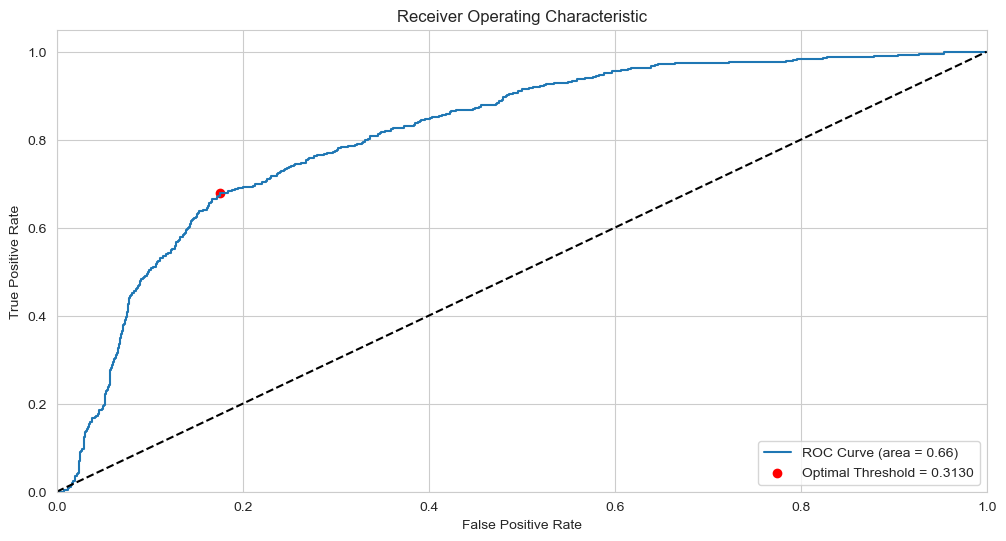

In [395]:
logistic_roc_auc = roc_auc_score(y_test, model_log_reg.predict(X_test))
print("Logistic Regression AUC = ", logistic_roc_auc)

y_pred_prob_log_reg = model_log_reg.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_log_reg[:,1])

youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]
print(f"Optimal Threshold: {optimal_threshold:.4f}")

plt.figure()
plt.plot(fpr, tpr, label = 'ROC Curve (area = %0.2f)' %logistic_roc_auc)
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0,1],[0,1],'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc='lower right')
plt.show()

## Random Forest ->

Random Forest AUC =  0.9872644595896102
Optimal Threshold: 0.5000


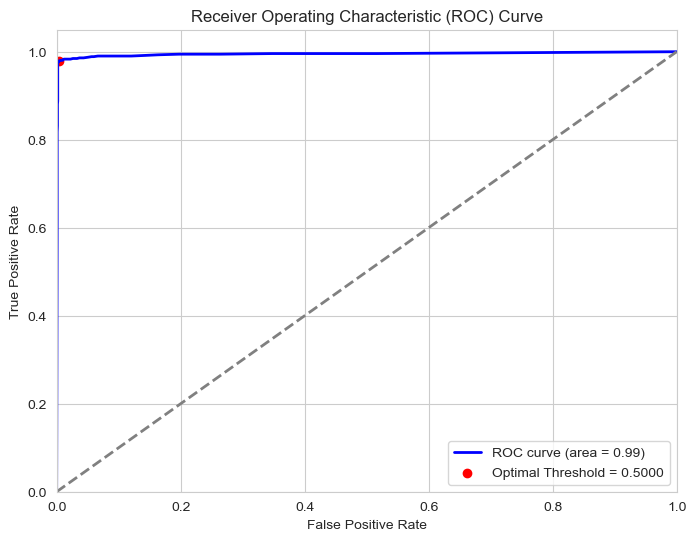

In [397]:
random_roc_auc = roc_auc_score(y_test, model_ran_for.predict(X_test))
print("Random Forest AUC = ", random_roc_auc)

y_pred_prob_ran_for = model_ran_for.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_ran_for[:,1])

youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]
print(f"Optimal Threshold: {optimal_threshold:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {random_roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## Gradient Boost ->

Gradient Boost AUC =  0.9602182080181154
Optimal Threshold: 0.5293


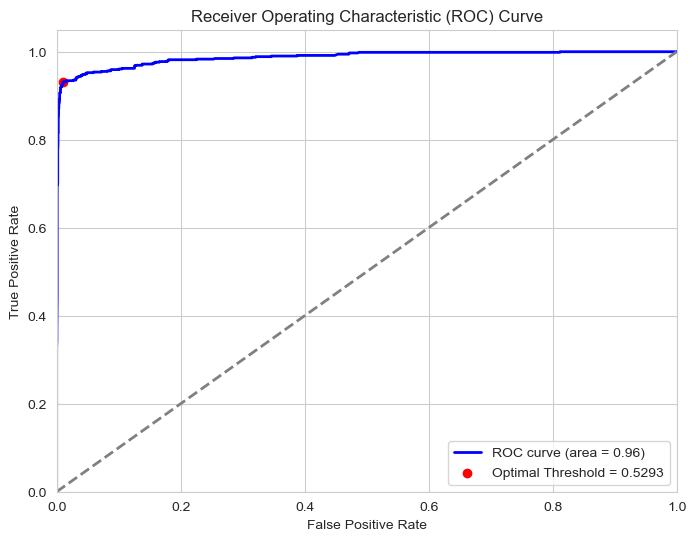

In [399]:
grad_roc_auc = roc_auc_score(y_test, model_grad_boo.predict(X_test))
print("Gradient Boost AUC = ", grad_roc_auc)

y_pred_prob_grad_boo = model_grad_boo.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_grad_boo[:,1])

youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]
print(f"Optimal Threshold: {optimal_threshold:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {grad_roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# 6.2. Find the confusion matrix for each of the models.

## Logistic Regression ->

Confusion Matrix:
[[2113  173]
 [ 429  285]]


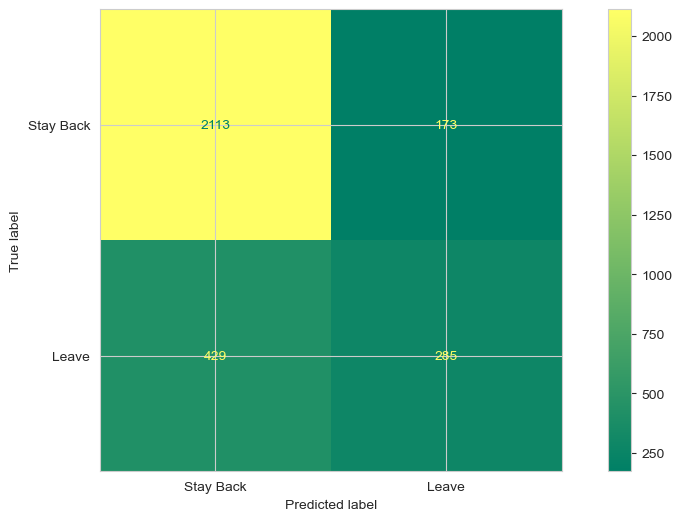

In [379]:
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_test_log_reg)
print("Confusion Matrix:")
print(conf_matrix_log_reg)

cm_display_log_reg = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_log_reg, display_labels = ["Stay Back", "Leave"])

cm_display_log_reg.plot(cmap='summer')
plt.show()

## Random Forest ->

Confusion Matrix:
[[2279    7]
 [  16  698]]


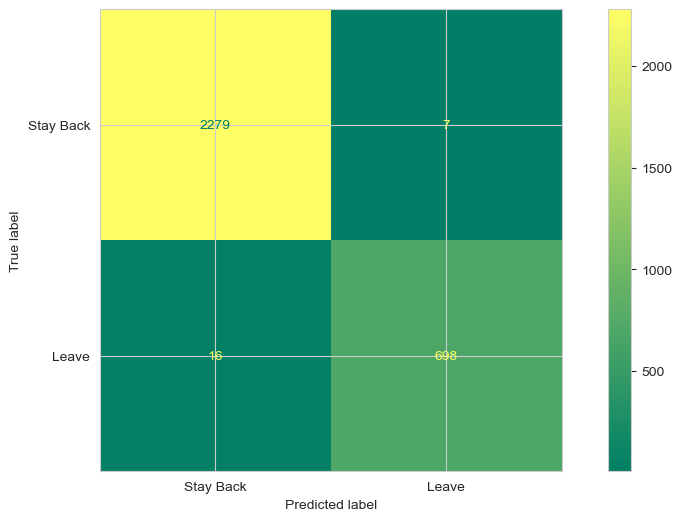

In [377]:
conf_matrix_ran_for = confusion_matrix(y_test, y_pred_test_ran_for)
print("Confusion Matrix:")
print(conf_matrix_ran_for)

cm_display_ran_for = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_ran_for, display_labels = ["Stay Back", "Leave"])

cm_display_ran_for.plot(cmap='summer')
plt.show()

## Gradient Boost ->

Confusion matrix:
[[2261   25]
 [  49  665]]


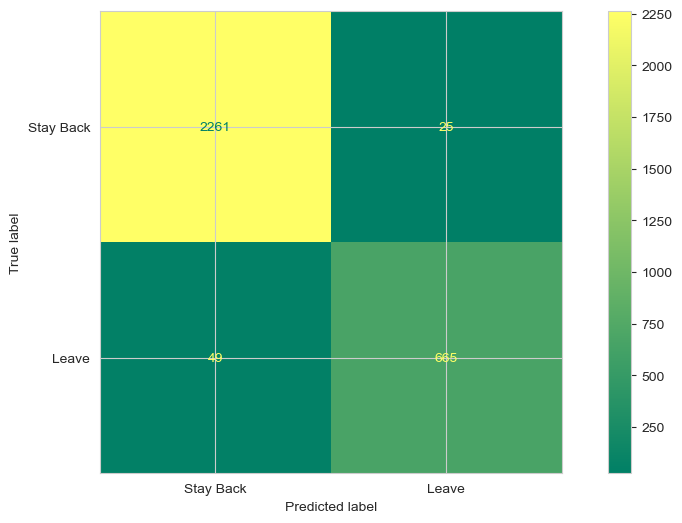

In [383]:
conf_matrix_grad_boo = confusion_matrix(y_test, y_pred_test_grad_boo)
print('Confusion matrix:')
print(conf_matrix_grad_boo)

cmap='summer'
display_labels=['Stay Back','Leave']
cm_display_grad_boo = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_grad_boo, display_labels=display_labels)
cm_display_grad_boo.plot(cmap=cmap)
plt.show()

# 6.3. Explain which metric needs to be used from the confusion matrix: Recall or Precision?

## Based on the Confusion Matrix, the False Negatives should be low because if an employee who might leave the organisation is misclassified as someone who would stay back, then proper strategies to retain that person will not be implemented. Hence, Recall is the better metric to be used.

# 7.1. Using the best model, predict the probability of employee turnover in the test data.

* Random Forest model shows the highest training and testing accuracies indicating good overall performance. The synergy in training and testing accuracies indicates that the model generalizes well without overfitting.

* The ROC Curve for Random Forest model reaches the top-left corner (TPR = 1, FPR = 0), which indicates a perfect classification performance. The model perfectly distinguishes between the employees staying back and leaving at various threshold settings. Moreover, the ROC Curve for the Random Forest model has Area Under the Curve (AUC) of 0.99. This indicates excellent discriminatory ability, meaning the classifier is highly capable of distinguishing between the classes of employees.

* The Classification Report measures (such as Precision and Recall) for the Random Forest model provides the best figures among all the models.

### Considering the above points we can safely take the Random Forest model to be the best.

In [411]:
features = pd.DataFrame()

In [409]:
labels = list(X_train.columns)
labels

['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'promotion_last_5years',
 'sales_RandD',
 'sales_accounting',
 'sales_hr',
 'sales_management',
 'sales_marketing',
 'sales_product_mng',
 'sales_sales',
 'sales_support',
 'sales_technical',
 'sales_nan',
 'salary_low',
 'salary_medium',
 'salary_nan']

In [421]:
importance = list(model_ran_for.feature_importances_)
importance

[0.31340175292804545,
 0.12423179740287767,
 0.1847085119888711,
 0.1545162978828628,
 0.1798999802760716,
 0.010546445260449115,
 0.0017178812363022253,
 0.00165035730135699,
 0.0018296885139554141,
 0.0015397438954499216,
 0.001554083586314467,
 0.0011801237934656434,
 0.001187791027385932,
 0.0033616072047451817,
 0.0028688030614373865,
 0.0037575516118683464,
 0.0,
 0.008144320627929422,
 0.003903262400611484,
 0.0]

In [427]:
features['variables'] = labels
features['importance'] = importance
features.sort_values(by=['importance'], ascending=True, inplace=True)
features['positive'] = features['importance'] > 0
features.set_index('variables', inplace=True)
features

,importance,positive
variables,,
salary_nan,0.000000,False
sales_nan,0.000000,False
sales_marketing,0.001180,True
sales_product_mng,0.001188,True
sales_hr,0.001540,True
sales_management,0.001554,True
sales_RandD,0.001650,True
promotion_last_5years,0.001718,True
sales_accounting,0.001830,True


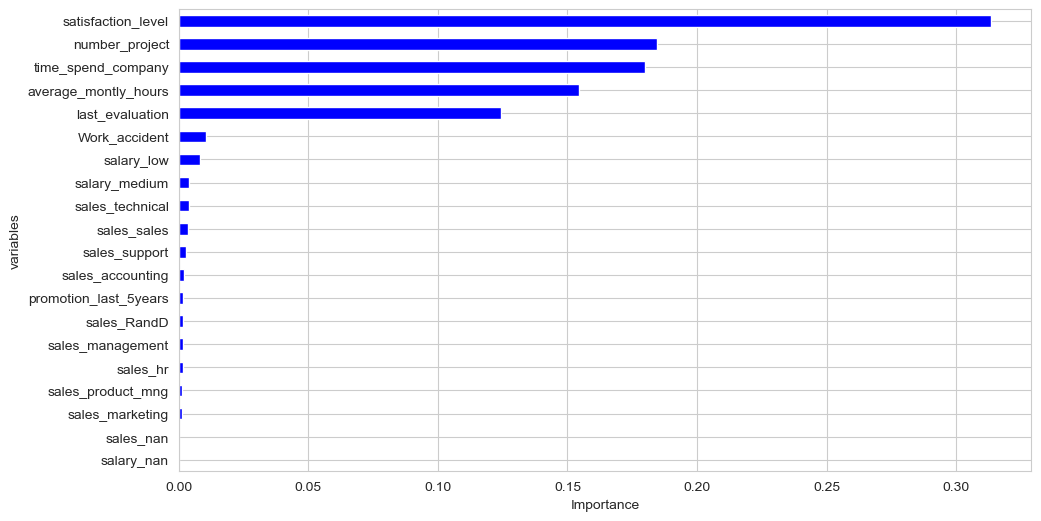

In [429]:
features.importance.plot(kind = 'barh', figsize=(11, 6), color = features.positive.map({True: 'blue', False: 'red'}))
plt.xlabel('Importance');
plt.show()

### The above lists the factors that influences the turnover in the ascending order. It can be identified that the employee turnover is highly influenced by the employee's satisfaction level in the organisation. Improvement of work culture within the organiation can be a good way to prevent the employees from leaving the organisation.

In [432]:
y_pred_prob_ran_for = model_ran_for.predict_proba(X_test)
y_pred_prob_ran_for[:,1]

array([0.  , 0.47, 0.01, ..., 0.04, 0.01, 0.98])

# 7.2. Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.

- Safe Zone (Green) (Score < 20%)
- Low-Risk Zone (Yellow) (20% < Score < 60%)
- Medium-Risk Zone (Orange) (60% < Score < 90%)
- High-Risk Zone (Red) (Score > 90%).

In [464]:
Risk_Zone = []
Probability = []

for i in y_pred_prob_ran_for[:,1]:
  Probability.append(i)
  if (i<=0.2):
    Risk_Zone.append("Safe Zone")    
  elif (i>0.2 and i<=0.6):
    Risk_Zone.append("Low-Risk Zone")
  elif (i>0.6 and i<=0.9):
    Risk_Zone.append("Medium-Risk Zone")
  else:
    Risk_Zone.append("High-Risk Zone")

In [470]:
categories = ["Safe Zone","Low-Risk Zone","Medium-Risk Zone","High-Risk Zone"]
colors = ["Green","Yellow","Orange","Red"]
cat_color_dict = dict(zip(categories, colors))

In [504]:
employee_category = pd.DataFrame({"Probability":Probability, "Risk_Zone":Risk_Zone})
employee_category.head()

,Probability,Risk_Zone
0,0.00,Safe Zone
1,0.47,Low-Risk Zone
2,0.01,Safe Zone
3,0.00,Safe Zone
4,0.00,Safe Zone


In [506]:
employee_category["Risk_Color"] = employee_category["Risk_Zone"].apply(lambda x: cat_color_dict[x])
employee_category.head()

,Probability,Risk_Zone,Risk_Color
0,0.00,Safe Zone,Green
1,0.47,Low-Risk Zone,Yellow
2,0.01,Safe Zone,Green
3,0.00,Safe Zone,Green
4,0.00,Safe Zone,Green


In [498]:
c = ["Green","Yellow","Red","Orange"]

[Text(0.5, 1.0, 'Employee Turnover Risk Mapping')]

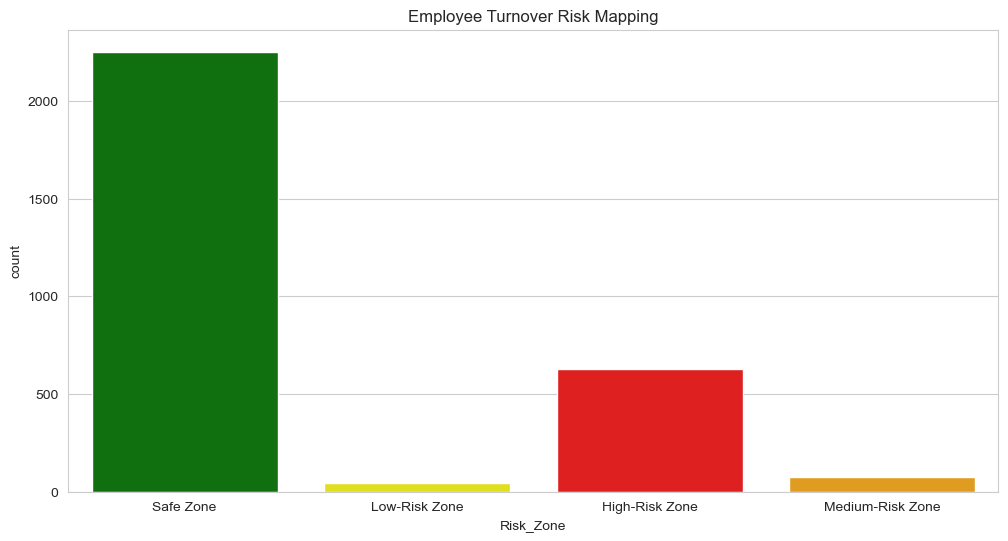

In [500]:
sns.countplot(x = employee_category['Risk_Zone'], palette = c).set(title = "Employee Turnover Risk Mapping")

### Employee retention strategies should be tailored based on the risk profile of each employee — categorized as Safe, Low, Medium, and High risk of leaving. Possible retention efforts are enlisted below.

### Safe ->
#### Characteristics: Highly engaged, satisfied, strong company loyalty, and long tenure.
#### Strategy:
- Recognize and reward contributions to maintain morale.
- Offer career development opportunities to keep them engaged.
- Foster a strong sense of purpose and belonging.
- Ensure they feel valued through leadership visibility and open communication.
- Encourage mentorship roles to reinforce their commitment.

### Low-Risk ->
#### Characteristics: Generally satisfied but could be tempted by external opportunities.
#### Strategy:
- Provide learning and development programs to keep skills relevant.
- Offer competitive salary adjustments and performance-based incentives.
- Maintain work-life balance through flexible work arrangements.
- Create opportunities for job rotation or internal mobility to avoid stagnation.
- Strengthen manager-employee relationships with regular check-ins.

### Medium-Risk ->
#### Characteristics: Signs of disengagement, lack of motivation, potential job hunting, or concerns with leadership/culture.
#### Strategy:
- Conduct stay interviews to understand concerns and areas of dissatisfaction.
- Personalize career growth plans with clear advancement paths.
- Improve leadership training to ensure managers foster a supportive environment.
- Address compensation gaps or offer targeted retention bonuses.
- Enhance recognition programs to boost motivation.

### High-Risk ->
#### Characteristics: Actively disengaged, vocal about dissatisfaction, possibly receiving external offers.
#### Strategy:
- Implement immediate intervention through leadership engagement.
- Offer retention bonuses or counteroffers (if aligned with company goals).
- Identify root causes (e.g., culture, workload, management issues) and address them.
- Provide fast-tracked promotions or critical role shifts (if feasible).
- Be prepared with succession planning in case of departure.
- By proactively identifying employees' risk levels and implementing targeted strategies, companies can reduce turnover and maintain a highly engaged workforce.